# Failures-To-Deliver — do settlement fails foreshadow a squeeze? 📉
### The meme-stock belief that 'FTD spike ⇒ shorts trapped ⇒ pop', in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Squeeze_predictor%3F: Busted](https://img.shields.io/badge/Squeeze_predictor%3F-Busted-8b949e?style=flat-square)

When you sell a share you're supposed to *deliver* it a couple of days later. Sometimes the seller doesn't — that's a **failure-to-deliver (FTD)**, a settlement fail, and the SEC publishes a running tally. During the meme-stock frenzy a story took hold: a **spike in FTD means short-sellers are trapped and can't deliver**, so a **short squeeze** — a violent upward move — must be coming. Buy the FTD spike, ride the pop.

It's a great story. We test it the honest way: build a realistic fake market where FTD spikes and stock moves are known to be *unrelated*, then ask whether an event study (look at what happens right after each spike) can tell the truth — and whether the seductive 'post-spike pop' survives.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** And a hard data caveat: there is **no free FTD price tape** (the SEC file is a bulk, twice-a-month, CUSIP-keyed list with no prices), so this study is deliberately **synthetic-only** — every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from failures_to_deliver import data, strategy as st

# There is NO free FTD tape (SEC bulk CUSIP flat file, no prices) -> synthetic-only, offline.
HAVE_REAL = not data.fetch_panel().empty   # always False by construction
print("real FTD tape present:", HAVE_REAL, "(synthetic-only study — no free FTD data)")

# The reproducible headline is the deterministic seed-558 NULL world (folklore off).
NULL_PANEL, _ = data.synthetic_panel(squeeze_alpha=0.0, seed=558)
print("null panel fp:", data.fingerprint(NULL_PANEL), "|", NULL_PANEL['name'].nunique(),
      "names x", NULL_PANEL['day'].nunique(), "days")


real FTD tape present: False (synthetic-only study — no free FTD data)


null panel fp: c0ab49b6db5b | 60 names x 756 days


## The answer first 🎯

| Question | Answer |
|---|---|
| After an FTD spike, is there a pop? | **No.** On a market built with *no* link between fails and returns, the post-spike abnormal return is **-0.029%** over 5 days (*t* -0.136). Basically zero. |
| Is that just because our fake is boring? | **No** — plant a *real* pop and the engine catches it easily (*t* +4.916 at a modest planted effect). The flat result is a *true* negative. |
| But I've seen convincing post-FTD-spike charts! | **So has everyone.** If you try enough horizons and thresholds, pure noise will hand you a scary-looking *t* > 2 — we show exactly that below. |
| Could you trade it? | **No** — and you can't even *get* the data cleanly. The FTD file is twice a month, lagged, keyed by CUSIP, with no prices. |

> The squeeze-from-fails story is microstructure **folklore**. Fails are mostly settlement plumbing and the cost of borrowing, not a cornered short.

## 1 · The claim

> *"When failures-to-deliver spike, shorts are trapped — a squeeze is coming, so the stock pops."* — meme-stock-era microstructure folklore.

The intuition feels airtight: if sellers *can't deliver*, surely they're desperate shorts who'll be forced to buy back at any price. But real fails happen for dull reasons — market-makers legitimately fail while hedging, options assignments settle late, borrow is briefly expensive. A fail is a plumbing event far more often than a cornered-short event.

## 2 · So what?

If the folklore were true it would be a money printer: watch the SEC fails file, buy every spike, collect the squeeze. The desk has already looked at the meme phenomenon itself ([213 Meme-Stocks](../../213-meme-stocks/)) and at short interest ([262 Short-Interest](../../262-short-interest/)); here we go straight at the specific **FTD-spike-as-squeeze-predictor** signal.

## 3 · How would we even know?

1. **Spot the spikes.** For each stock, flag the days its fails jump far above its own recent normal (a trailing z-score) — using only the *past*, so no cheating.
2. **Look forward.** After each spike, measure the next 5 days' return.
3. **Compare to the market.** Subtract what the average stock did over the same days, so we isolate the *abnormal* pop the folklore promises — not just a rising tide.

Two honesty guards: we only count spikes far enough apart that their forward windows don't overlap (overlapping windows fake confidence), and we enter *after* the spike day (no peeking at the move we're trying to predict).

*Data reality:* we can't do this on the real SEC file (twice-monthly, CUSIP-keyed, no prices), so we build a **faithful synthetic market** where we *know* the truth — fails and returns are unrelated — and check the engine gets it right.

## 4 · The teardown — let's actually look

**What happens in the 5 days after an FTD spike, versus the market?**

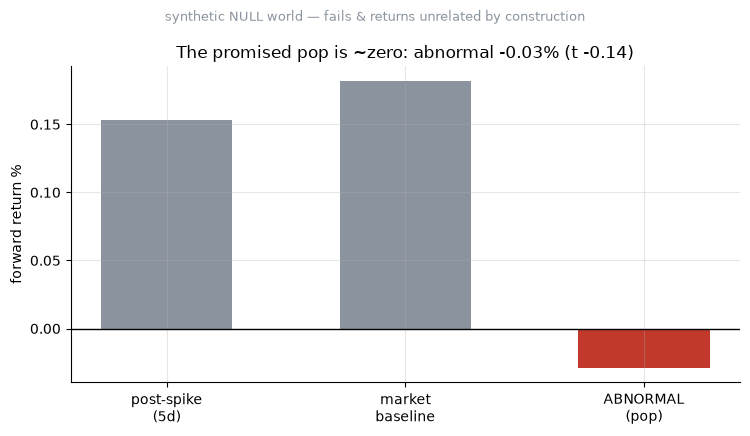

829 spike events | post-spike +0.15% | market +0.18% | ABNORMAL -0.03% (t -0.14)


In [2]:
es = st.event_study(NULL_PANEL, horizon=5, spike_z=2.5)
raw = es['mean_fwd']*100; base = es['baseline_mean']*100; abn = es['excess']*100
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['post-spike\n(5d)','market\nbaseline','ABNORMAL\n(pop)'],
       [raw, base, abn], color=[GREY, GREY, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'The promised pop is ~zero: abnormal {abn:+.2f}% (t {es["t"]:+.2f})')
fig.suptitle('synthetic NULL world — fails & returns unrelated by construction', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'{es["n_events"]} spike events | post-spike {raw:+.2f}% | market {base:+.2f}% | ABNORMAL {abn:+.2f}% (t {es["t"]:+.2f})')

There's the answer. The post-spike **abnormal** return is **-0.029%** — a rounding error — with a *t* of **-0.136**. No pop. And that's the truth we built in: in this world fails carry *no* information about future returns.

**"But I've seen charts where the pop is obvious!"** Here's the trap. Let's try lots of horizons (1, 3, 5, 10 days) and spike thresholds — on the *same noise* — and see what the biggest *t* we can find is:

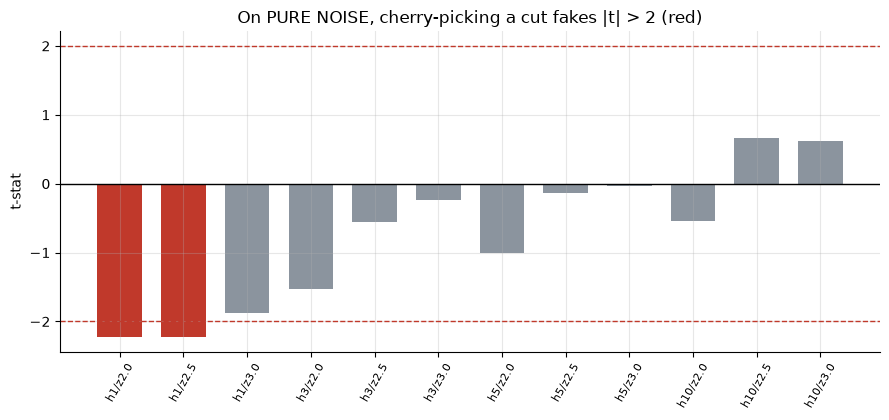

sweep t range: -2.23 to 0.67


In [3]:
sw = st.robustness_sweep(NULL_PANEL, horizons=(1,3,5,10), thresholds=(2.0,2.5,3.0))
fig, ax = plt.subplots(figsize=(9, 4.3))
labels = [f"h{int(r.horizon)}/z{r.spike_z}" for r in sw.itertuples()]
cols = [RED if abs(t)>2 else GREY for t in sw['t']]
ax.bar(range(len(sw)), sw['t'], color=cols, width=.7)
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xticks(range(len(sw)))
ax.set_xticklabels(labels, rotation=60, fontsize=8); ax.set_ylabel('t-stat')
ax.set_title('On PURE NOISE, cherry-picking a cut fakes |t| > 2 (red)')
plt.tight_layout(); plt.show()
print('sweep t range:', round(sw['t'].min(),2), 'to', round(sw['t'].max(),2))

There it is: on a market with **nothing** in it, the 1-day cut prints a *t* of about **-2.232** (the *wrong* sign, even). The sweep *t* runs **-2.232 → 0.67**. Hunt across enough horizons and thresholds and noise *will* hand you a significant-looking result. That striking post-FTD-spike chart you saw online is almost certainly one lucky cut.

## 5 · The verdict

- **Signal — None.** Post-spike abnormal return -0.029% (*t* -0.136), placebo *p* 0.513. And with no free FTD tape, `REAL` is off the table anyway.
- **Tradability — Mirage.** Nothing to harvest before costs; the FTD-spiking name is the costly-to-borrow tail; and the raw data isn't cleanly reachable.
- **Squeeze predictor? — Busted.** A sweep on pure noise fakes a *t* > 2 — the classic multiple-comparisons mirage.

## 6 · Could you actually trade it?

No — twice over. First, there's no edge to trade. Second, the raw signal isn't even usable: the SEC fails file lands *twice a month*, lagged by the settlement cycle, keyed by CUSIP (not ticker), with no prices attached. By the time you've stitched it to a clean, survivorship-free price panel, any fleeting 'signal' is long gone — and the names you'd be buying are exactly the hard-to-borrow ones a short trade hates.

## 7 · Going further 🚪

- **The neighbours.** [213 Meme-Stocks](../../213-meme-stocks/) (the return phenomenon) and [262 Short-Interest](../../262-short-interest/) (short interest / days-to-cover).
- **The engine isn't blind.** In the quant notebook we *plant* a real post-spike pop and watch the same test catch it past *t* +2 — proof the flat null here is a true negative.

*Think fails really do predict squeezes? Fork this, get a real CUSIP-linked FTD + price panel (survivorship-clean), and show the post-spike abnormal return clearing t = 2.*